In [1]:
import sys
sys.path.append("../")

# local imports
from batchAQUA_general import batchAQUA
from AQUA_general import AQUA
from stimulus import *
from plotting_functions import *

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq


In [2]:
IB = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0., 'f': 0., 'tau': 0.}
    
IB_aut = {'name': 'IB', 'C': 150, 'k': 1.2, 'v_r': -75, 'v_t': -45, 'v_peak': 50,
     'a': 0.01, 'b': 5, 'c': -56, 'd': 130, 'e': 0.2, 'f': 150., 'tau': 0.}

CH = {'name': 'CH', 'C': 50, 'k': 1.5, 'v_r': -60, 'v_t': -40, 'v_peak': 25, 
     'a': 0.03, 'b': 1, 'c': -40, 'd': 150, 'e': 0., 'f': 0., 'tau': 0.}


neuron = AQUA(IB)

threshold, x_ini = neuron.get_threshold()

100%|██████████| 39999/39999 [00:05<00:00, 7650.00it/s]


100%|██████████| 249999/249999 [00:30<00:00, 8228.26it/s]


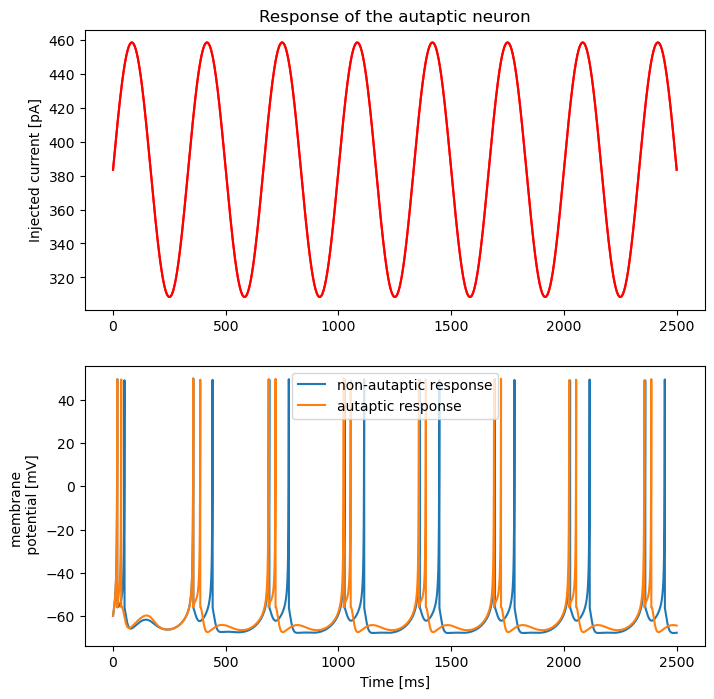

In [8]:
### INPUT is a sinusoid

T = 2500         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

freq = 3 # Hz (Kepecs et al.)
amp = 75
phase = 0

x_ini = np.array([-60, 0, 0])

# pick params here
params = [IB, IB_aut]

batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# define the injected current
I_sin, _ = sinusoid(N_iter, dt, freq, amp, phase)
I_sin += threshold + amp

I_inj = np.array([I_sin, I_sin])

# simulate
X_sin, time, spikes_sin = batch.update_batch(dt, N_iter, I_inj)

## plot the outputs

fig, ax = plt.subplots(2, 1, figsize = (8, 8))

#split = np.arange(90000, 120000)
split = []
label = 'non-autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[0], time, I_sin, fig = fig, ax = ax, label = label) # non-autaptic

label = 'autaptic response'
fig, ax = plot_potential_versus_injected(X_sin[1], time, I_sin, fig = fig, ax = ax, label = label) # autaptic
ax[0].set_title("Response of the autaptic neuron")

plt.legend()
plt.show()



[[  18.81         50.67        355.95        441.43        693.16
   779.65       1027.09       1113.8        1360.52       1447.25
  1693.87       1780.62       2027.2        2113.93       2360.53000001
  2447.26000001]
 [  18.81         36.31        355.94        386.99        690.08
   720.88       1023.46       1054.25       1356.79       1387.57
  1690.12       1720.9        2023.45       2054.22       2356.78000001
  2387.55000001]]
[ 31.86       305.28        85.48       251.73        86.49
 247.44        86.71       246.72        86.73       246.62
  86.75       246.58        86.73       246.60000001  86.73      ]


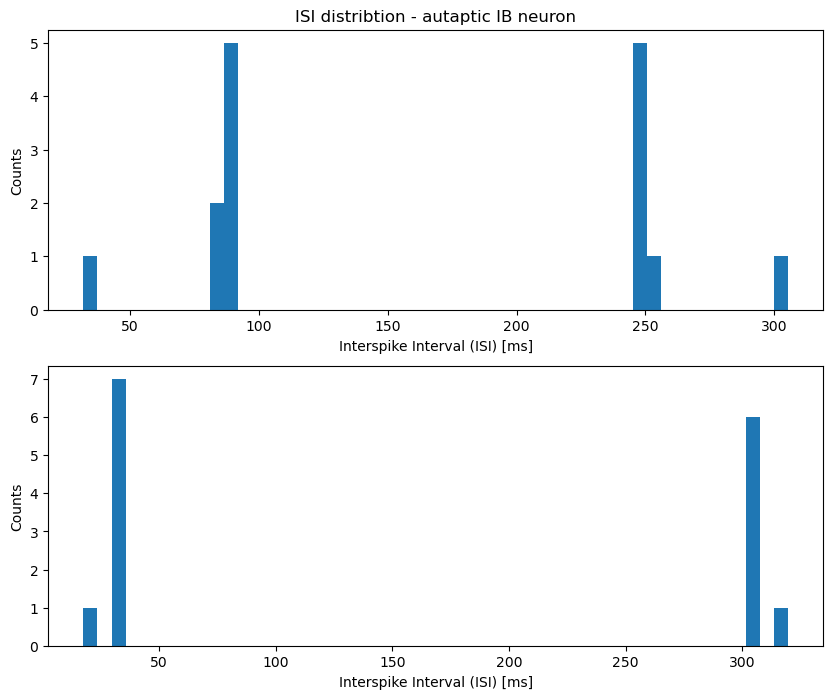

In [9]:
""" SPIKE TIMES """
print(spikes_sin)
print(np.ediff1d(spikes_sin[0]))


fig, ax = plt.subplots(2, 1, figsize = (10, 8))
fig, ax[0] = plot_ISI_dist(spikes_sin[0], fig = fig, ax = ax[0])
ax[0].set_title("ISI distribtion - non-autaptic IB neuron")
fig, ax[1] = plot_ISI_dist(spikes_sin[1], fig = fig, ax = ax[1])
ax[0].set_title("ISI distribtion - autaptic IB neuron")
plt.show()

In [10]:
### INPUT is filtered white noise

T = 5000         # ms
dt = 0.01        # ms
N_iter = int(T/dt)

x_ini = np.array([-60, 0, 0])

# pick params here
params = [IB, IB_aut]

batch = batchAQUA(params) 
batch.Initialise(np.array([x_ini, x_ini]), np.zeros(len(params)))

# define the injected current
offset = 50
amplitude = 100
cutoff = 5    # Hz
I_fwn = filtered_white_noise(T/1000, dt, amplitude = amplitude, cutoff = cutoff, poles = 10)
I_fwn += threshold + offset

I_inj = np.array([I_fwn, I_fwn])


# simulate
X_fwn, time, spikes_fwn = batch.update_batch(dt, N_iter, I_inj)



100%|██████████| 499999/499999 [01:01<00:00, 8105.97it/s]


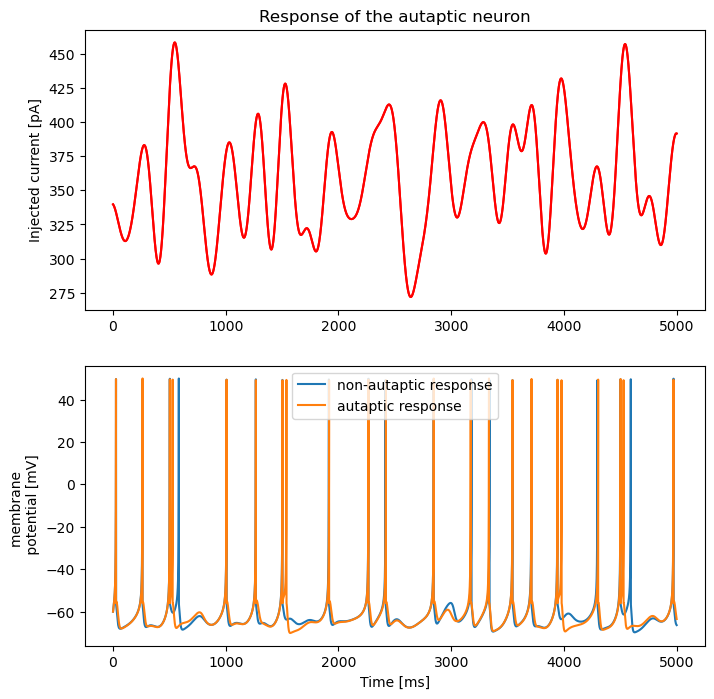

In [11]:
# plot outputs

fig, ax = plt.subplots(2, 1, figsize = (8, 8))

#split = np.arange(200000, 300000)
split = []
label = 'non-autaptic response'
fig, ax = plot_potential_versus_injected(X_fwn[0], time, I_fwn, split = split, fig = fig, ax = ax, label = label) # non-autaptic

label = 'autaptic response'
fig, ax = plot_potential_versus_injected(X_fwn[1], time, I_fwn, split = split, fig = fig, ax = ax, label = label) # autaptic
ax[0].set_title("Response of the autaptic neuron")

plt.legend()
plt.show()

[  26.3         260.84        503.76        583.67       1007.14
 1266.78       1502.64       1914.95       2265.67       2417.49000001
 2844.79000002 3179.52000002 3339.31000003 3543.97000003 3710.92000003
 3942.53000004 4296.87000005 4501.23000005 4592.99000005 4972.08000006
           nan           nan]
[234.54       242.92        79.91       423.47       259.64
 235.86       412.31       350.72       151.82       427.30000001
 334.73000001 159.79       204.66       166.95       231.61000001
 354.34000001 204.36        91.76       379.09000001          nan
          nan]
- - - - - - -
[  26.3         261.86        504.15        528.95       1007.14
 1267.2        1503.39       1538.1        1916.57       2266.08
 2420.78000001 2844.91000002 3173.28000002 3334.98000003 3543.36000003
 3712.61000003 3943.26000004 3978.59000004 4303.47000005 4502.77000005
 4529.20000005 4971.51000006]
[235.56       242.29        24.8        478.19       260.06
 236.19        34.71       378.47       349

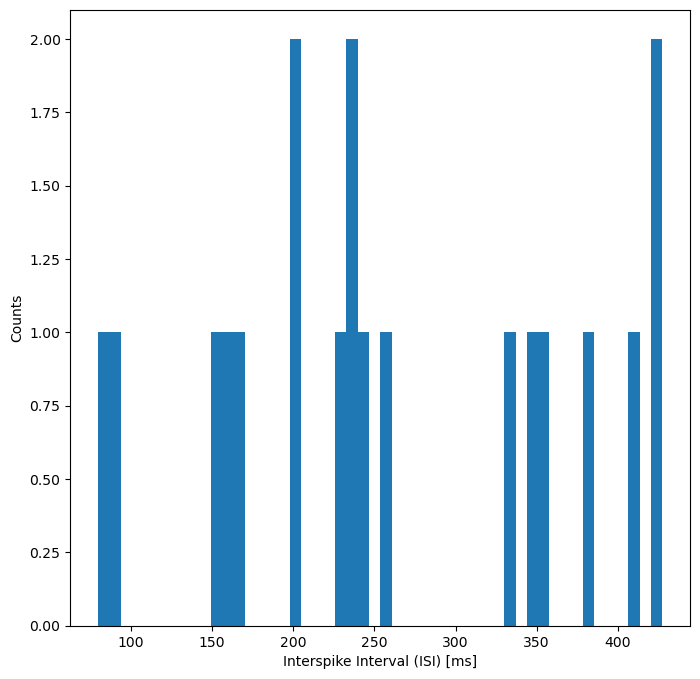

In [12]:
# 
print(spikes_fwn[0])
print(np.ediff1d(spikes_fwn[0]))
print("- - - - - - -")
print(spikes_fwn[1])
print(np.ediff1d(spikes_fwn[1]))
print("- - - - - - -")


fig, ax = plot_ISI_dist(spikes_fwn[0])

#plt.plot(spikes_fwn[0])

plt.show()